In [1]:
#This part of the code loads our training data,
#extracts the images and their matching labels
#uses the extracted data to train a model
#saves the model and plots the metrics/loss over the epochs


import cv2
import re
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
import keras
from keras import models, layers, backend
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, AvgPool2D, BatchNormalization, Dropout, Activation, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from keras import regularizers
from keras.layers.advanced_activations import LeakyReLU
from keras.models import Sequential, Model
from keras.layers import PReLU, ReLU, Activation, Convolution2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout, Conv2D, MaxPool2D, ZeroPadding2D, GaussianNoise, SeparableConv2D, Input
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TerminateOnNaN, CSVLogger

ModuleNotFoundError: No module named 'cv2'

In [2]:
print(os.getcwd())

/tf/work_directory


In [3]:
#directory asignements

main_dir = os.getcwd()
img_train_dir = os.path.join(main_dir, "Dataset", "Images_Ref_Points")
labels_dir = os.path.join(main_dir, "Dataset")
models_dir = os.path.join(main_dir, "Models")

In [4]:
#helper function to iterate through directories alphanumerically

def sorted_alphanumeric(data):
    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda key: [ convert(c) for c in re.split('([0-9]+)', key) ] 
    return sorted(data, key=alphanum_key)

In [5]:
#normalizing the channels of the image to a between [0,1]

def normalize_values(dataset):
    normalized_data = dataset / 255.0
    return normalized_data

def rescale_values(dataset):
    rescaled_data = np.uint8(dataset * 255.0)
    return rescaled_data

In [6]:
#Global variables to pass as arguments to the data generation

NORMALIZE_DATA = True
NORMALIZE_LABELS = True

In [7]:
#Images as numpy arrays

#size: when passed as an argument takes the first n-number of images in the dataset

def image_to_numpy(img_dir, size=None, normalize=True):
    os.chdir(img_dir)
    sorted_files = sorted_alphanumeric(os.listdir(img_dir))

    dataset = []

    for file in sorted_files:
        img = Image.open(file)
        imgArray = np.array(img)
        dataset.append(imgArray)

    dataset = np.array(dataset)
    print("Data generated...")
    
    if normalize == True:
        dataset = normalize_values(dataset)
        print("Data normalized...")
    
    if size != None:
        assert isinstance(size, int)
        normalized_dataset_split = dataset[:size]
        
        print("Data split to new size ", size)
        print("Shape: ", normalized_dataset_split.shape, " Type: ", type(normalized_dataset_split), " dtype: ", normalized_dataset_split.dtype)
        
        return normalized_dataset_split
    
    print("Shape: ", dataset.shape, " Type: ", type(dataset), " dtype: ", dataset.dtype)
    
    return dataset, size

In [8]:
#Labels of the data as numpy arrays

#img_width: denominator for normalizing labels (assumption: square image with same dimensions)

def coords_to_numpy(labels_dir, csv_name, img_width=None, size=None, normalize=True):
    os.chdir(labels_dir)

    coords = []
    ref_points = []
    ref_center = []
    
    with open(csv_name, 'r') as file:
        csv_reader = csv.reader(file)
        csv_reader_list = list(csv_reader)
        
        ref_row = csv_reader_list[0]
        
        ref_points = list(int(x) for x in ref_row[0].replace("[", "").replace("]", "").replace("(", "").replace(")", "").split(','))
        
        ref_center = list(int(x) for x in ref_row[1].strip('()').split(','))
        
        for row in csv_reader_list[1:]:
            c_xy = []
            
            for tup in row:
                c_xy.extend(int(x) for x in tup.strip('()').split(','))
            
            coords.append(c_xy)
            
    coords = np.asarray(coords)
    ref_points = np.asarray(ref_points)
    ref_center = np.asarray(ref_center)
    
    print("Labels generated from: ", csv_name)
    
    if normalize == True and img_width != None:
        assert isinstance(img_width, int)
        
        coords = coords / img_width
        ref_points = ref_points / img_width
        ref_center = ref_center / img_width
        
        print("Labels normalized...")
    
    if size != None:
        assert isinstance(size, int)
        
        coords_split = coords[:size]
        
        print("Labels split to new size: ", size)
        print("Shape: ", coords_split.shape, " Type: ", type(coords_split), " dtype: ", coords_split.dtype)
        
        return coords_split, ref_points, ref_center
    
    print("Shape: ", coords.shape, " Type: ", type(coords), " dtype: ", coords.dtype)
    
    return coords, ref_points, ref_center

In [9]:
#Dataset and corresponding label generation

X_train , labels_size = image_to_numpy(img_train_dir, normalize=NORMALIZE_DATA)
y_train, ref_coords, ref_center = coords_to_numpy(labels_dir, "labels_ref_points.csv", img_width=X_train.shape[1], size=labels_size, normalize=NORMALIZE_LABELS)

#Global variables to be passed to the model training process

INPUT_SHAPE = X_train.shape[1:]
OUTPUT = y_train.shape[1]

#Assert if the data was actually normalized if normalize == True

if NORMALIZE_DATA == True:
    assert X_train.max() <= 1.0 and X_train.min() >= 0.0

if NORMALIZE_LABELS == True:    
    assert y_train.max() <= 1.0 and y_train.min() >= 0.0
    assert ref_coords.max() <= 1.0 and ref_coords.min() >= 0.0
    assert ref_center.max() <= 1.0 and ref_center.min() >= 0.0

print("Reference points: ", ref_coords, ref_coords.shape)
print("Reference center: ", ref_center, ref_center.shape)
print("Input shape: ", INPUT_SHAPE, " Number of Outputs: ", OUTPUT)

Data generated...
Data normalized...
Shape:  (2000, 256, 256, 3)  Type:  <class 'numpy.ndarray'>  dtype:  float64
Labels generated from:  labels_ref_points.csv
Labels normalized...
Shape:  (2000, 8)  Type:  <class 'numpy.ndarray'>  dtype:  float64
Reference points:  [0.27734375 0.27734375 0.72265625 0.27734375 0.27734375 0.71875
 0.72265625 0.71875   ] (8,)
Reference center:  [0.5 0.5] (2,)
Input shape:  (256, 256, 3)  Number of Outputs:  8


In [10]:
def custom_loss(y_true, y_pred):
    
    #reshape labels of each element of the batch such that the rows are the coord dimensions
    C_p = tf.cast(tf.reshape(y_pred, [-1, 4, 2]), dtype=tf.float64)
    #transpose each entry in the tensor
    C_p = tf.einsum('bij->bji', C_p)
    
    #create matrix to select the points to be subtracted
    c_selector = tf.constant([[-1.0, 0.0, 0.0, -1.0],
                              [0.0, 0.0, 1.0, 1.0],
                              [1.0, 1.0, 0.0, 0.0],
                              [0.0, -1.0, -1.0, 0.0]], dtype=tf.float64)
    
    #dot product of C_p and C_selector for each element of the batch (implicit broadcasting)
    E_p = tf.linalg.matmul(C_p, c_selector)
    
    #transpose each entry of the tensor
    E_p_transpose = tf.einsum('bij->bji', E_p)
    
    #take the dot product of the matrix with itself to create a new matrix
    #new matrix is symmetrical and contains the square of the norms of each e_vector on its main diag 
    #and the scalar of each combination of e_vectors
    E = tf.linalg.matmul(E_p_transpose, E_p)
    
    #select diagonals of each matrix to get the square of the norms for each element in the batch
    norms = tf.math.sqrt(tf.linalg.diag_part(E))
    norms = tf.reshape(norms, [-1, 1, norms.shape[1]])
    
    #norm_selector helps us in reordering the entries in our norms vector
    #is used to get the product of the desired norms by aligning the entries correctly
    norms_selector = tf.constant([[0., 0., 0., 1.],
                                  [1., 0., 0., 0.],
                                  [0., 1., 0., 0.],
                                  [0., 0., 1., 0.]], dtype=tf.float64)
    
    
    #vector containing the reciprocal of the products of the norms
    norms_denominator = tf.math.reciprocal(norms * tf.linalg.matmul(norms, norms_selector))
    norms_denominator_transpose = tf.einsum('bij->bji', norms_denominator)
    
    #creating a vector containing each of the desired scalar products of E
    
    #first three entries are in the first sub-diagonal below the main diagonal
    scalar_123 = tf.linalg.diag_part(E, k=-1)
    
    #fourth entry is the last one in the first column (reshape, to match ranks for concatenation)
    scalar_4 = tf.reshape(E[:, -1, 0], [-1, 1])
    
    #concatonate the fourth entry to the vector with the first three entries to get desired vector
    e_scalar = tf.concat([scalar_123, scalar_4], 1)
    
    #reshape to match the dimensions
    e_scalar = tf.reshape(e_scalar, [-1, 1, e_scalar.shape[1]])
    
    #scalar product of norms_denominator and e_scalar
    #returns the sum of all cos values for each angle as the perpendicularity_fac
    perpendicularity_fac = tf.linalg.matmul(e_scalar, norms_denominator_transpose)
    
    #calculate loss
    perp_sqr_error = tf.math.square(perpendicularity_fac)
    perp_mean_sqr_error = tf.reduce_mean(perp_sqr_error)
    
    error = tf.cast(y_true - y_pred, dtype=tf.float64)
    sqr_error = tf.math.square(error)
    mean_sqr_error = tf.reduce_mean(sqr_error)
    
    loss = mean_sqr_error + perp_mean_sqr_error
    
    return loss

In [11]:
#Preprocessing reference data

R_c = tf.cast(tf.transpose(tf.reshape(ref_coords, [-1, 2])), dtype=tf.float64)
R_center = tf.cast(tf.reshape(ref_center, [-1, 2]), dtype=tf.float64)

print("ref_coords:", R_c.shape, type(R_c))
print("ref_center:", R_center.shape, type(R_center))

X_WEIGHT = 1.0
Y_WEIGHT = 1.0
ANGLE_WEIGHT = 1.0

METRIC_WEIGHTS = tf.transpose(tf.constant([[X_WEIGHT, Y_WEIGHT, ANGLE_WEIGHT]], dtype=tf.float64))

ref_coords: (2, 4) <class 'tensorflow.python.framework.ops.EagerTensor'>
ref_center: (1, 2) <class 'tensorflow.python.framework.ops.EagerTensor'>


In [12]:
def custom_metric(y_true, y_pred):
    #reshape labels of each element of the batch such that the rows are the coord dimensions
    C_p = tf.cast(tf.reshape(y_pred, [-1, 4, 2]), dtype=tf.float64)
    #transpose each entry in the tensor
    C_p = tf.einsum('bij->bji', C_p)
    
    #previous two operations for the actual labels
    C_t = tf.cast(tf.reshape(y_true, [-1, 4, 2]), dtype=tf.float64)
    C_t = tf.einsum('bij->bji', C_t)
    
    #helper matrix to calculate the necessary edge vectors
    selector = tf.constant([[1.],
                            [0.],
                            [-1.],
                            [0.]], dtype=tf.float64)
    
    #calculating the center of all four points for both the actual and predicted labels
    center_xt = tf.reshape(tf.math.reduce_mean(C_t[:, 0, :], axis=1), [-1, 1])
    center_yt = tf.reshape(tf.math.reduce_mean(C_t[:, 1, :], axis=1), [-1, 1])
    
    center_xp = tf.reshape(tf.math.reduce_mean(C_p[:, 0, :], axis=1), [-1, 1])
    center_yp = tf.reshape(tf.math.reduce_mean(C_p[:, 1, :], axis=1), [-1, 1])
    
    center_t = tf.concat([center_xt, center_yt], axis=1)
    center_p = tf.concat([center_xp, center_yp], axis=1)
    
    
    #difference between the properly placed center and the misplaced center
    offset_t = ref_center - center_t
    offset_p = ref_center - center_p
    
    #mean error of the x and y offset predictions
    delta_xy = tf.reshape(tf.reduce_mean(offset_t - offset_p, axis=0), [1, -1])
    
    #extract the necessary edge vector from the actual and predicted labels
    et_13 = tf.linalg.matmul(C_t, selector)
    et_13 = tf.reshape(et_13, [-1, 1, et_13.shape[1]])
    
    ep_13 = tf.linalg.matmul(C_p, selector)
    ep_13 = tf.reshape(ep_13, [-1, 1, ep_13.shape[1]])
    
    #reference edge for angle calculation
    e_r = tf.linalg.matmul(R_c, selector)
    
    #scalar product for the left edge and the upward vector (numerator)
    scalar_t = tf.linalg.matmul(et_13, e_r)
    
    #scalar product for the left edge and the upward vector (numerator)
    scalar_p = tf.linalg.matmul(ep_13, e_r)
    
    #norms of the all vectors (denominator)
    e_r_norm = tf.norm(e_r)
    
    et_13_norm = tf.norm(et_13, axis=2)
    et_13_norm = tf.reshape(et_13_norm, [-1, 1, et_13_norm.shape[1]])
    
    ep_13_norm = tf.norm(ep_13, axis=2)
    ep_13_norm = tf.reshape(ep_13_norm, [-1, 1, ep_13_norm.shape[1]])
    
    #angle calculation for the actual and predicted labels (arc cos of angle formula for angle between two vectors)
    angle_t = tf.math.acos(tf.math.divide_no_nan(scalar_t, tf.math.multiply_no_nan(et_13_norm, e_r_norm)))
    angle_p = tf.math.acos(tf.math.divide_no_nan(scalar_p, tf.math.multiply_no_nan(ep_13_norm, e_r_norm)))
    
    #mean error of the angle prediction
    delta_angle = tf.reshape(tf.reduce_mean(angle_t - angle_p), [1, -1])
    
    #unify the errors of the coordinates and angles in a single vector
    delta = tf.math.abs(tf.concat([delta_xy, delta_angle], axis=1))
    
    #weighted sum of all mean errors as our metric
    metric = tf.linalg.matmul(delta, METRIC_WEIGHTS)
    
    return metric

In [13]:
#EXAMPLE MODEL FOR GENERAL TESTING, NOT FINAL

def get_model():
    # Load the pre-trained weights of MobileNetV2 and freeze the weights
    backbone = keras.applications.MobileNetV2(
        weights="imagenet", include_top=False, input_shape=INPUT_SHAPE
    )
    backbone.trainable = False

    inputs = layers.Input(INPUT_SHAPE)
    x = GaussianNoise(0.1)(inputs)
    x = keras.applications.mobilenet_v2.preprocess_input(x)
    x = backbone(x)
    x = layers.Dropout(0.3)(x)
    x = layers.SeparableConv2D(
        OUTPUT, kernel_size=5, strides=1, activation="relu"
    )(x)
    
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.1)(x)
    outputs = Dense(OUTPUT)(x)
    
    #x = layers.SeparableConv2D(
    #    OUTPUT, kernel_size=3, strides=1, activation="relu"
    #)(x)
    
    return keras.Model(inputs, outputs, name="keypoint_detector")

In [14]:
model = Sequential()

model.add(Input(INPUT_SHAPE))
model.add(GaussianNoise(0.1))

model.add(Convolution2D(8, (1,1), padding='same', use_bias=False))
model.add(LeakyReLU(alpha = 0.1))
model.add(BatchNormalization())

model.add(Convolution2D(8, (1,1), padding='same', use_bias=False))
model.add(LeakyReLU(alpha = 0.1))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Convolution2D(8, (1,1), padding='same', use_bias=False))
model.add(LeakyReLU(alpha = 0.1))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Convolution2D(8, (1,1), padding='same', use_bias=False))
model.add(LeakyReLU(alpha = 0.1))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Convolution2D(8, (1,1), padding='same', use_bias=False))
model.add(LeakyReLU(alpha = 0.1))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Convolution2D(8, (1,1), padding='same', use_bias=False))
model.add(LeakyReLU(alpha = 0.1))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Convolution2D(8, (1,1), padding='same', use_bias=False))
model.add(LeakyReLU(alpha = 0.1))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))


model.add(Flatten())
model.add(Dropout(0.1))
model.add(Dense(OUTPUT))

In [15]:
#model = get_model()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise (GaussianNoi  (None, 256, 256, 3)      0         
 se)                                                             
                                                                 
 conv2d (Conv2D)             (None, 256, 256, 8)       24        
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 256, 256, 8)       0         
                                                                 
 batch_normalization (BatchN  (None, 256, 256, 8)      32        
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 256, 256, 8)       64        
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 256, 256, 8)       0

In [16]:
#custom metrics not yet implemented
model.compile(optimizer='Adam', 
              loss=custom_loss,
              metrics=[custom_metric])

In [17]:
os.chdir(os.path.join(models_dir, "Model_Logs"))
csv_logger = CSVLogger(filename='cl_cm_test_logs.csv',
                       separator=',',
                       append=True)

early_stopping = EarlyStopping(monitor='val_loss',
                               min_delta=0.0,
                               patience=30,
                               verbose=1,
                               restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=5, min_lr=0.001)

callbacks = [csv_logger,
             reduce_lr]

In [18]:
history = model.fit(X_train, y_train, validation_split=0.3, epochs=3000, callbacks=callbacks)

Epoch 1/3000
44/44 [==============================] - 6s 78ms/step - loss: 4.6776 - custom_metric: 2.0809 - val_loss: 0.4282 - val_custom_metric: 1.4818 - lr: 0.0010
Epoch 2/3000
44/44 [==============================] - 2s 54ms/step - loss: 2.8168 - custom_metric: 1.0035 - val_loss: 0.6305 - val_custom_metric: 1.5675 - lr: 0.0010
Epoch 3/3000
44/44 [==============================] - 2s 55ms/step - loss: 2.0459 - custom_metric: 0.7563 - val_loss: 0.5285 - val_custom_metric: 2.3651 - lr: 0.0010
Epoch 4/3000
44/44 [==============================] - 2s 54ms/step - loss: 1.5804 - custom_metric: 0.6956 - val_loss: 0.6087 - val_custom_metric: 3.5325 - lr: 0.0010
Epoch 5/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.2509 - custom_metric: 0.5591 - val_loss: 0.7501 - val_custom_metric: 3.6295 - lr: 0.0010
Epoch 6/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.0917 - custom_metric: 0.5324 - val_loss: 3.5274 - val_custom_metric: 3.6416 - lr: 0.0010
Epoc

44/44 [==============================] - 2s 55ms/step - loss: 0.0141 - custom_metric: 0.1847 - val_loss: 0.0424 - val_custom_metric: 0.6112 - lr: 0.0010
Epoch 100/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0136 - custom_metric: 0.1742 - val_loss: 0.0391 - val_custom_metric: 0.6491 - lr: 0.0010
Epoch 101/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0135 - custom_metric: 0.1842 - val_loss: 0.0393 - val_custom_metric: 0.5792 - lr: 0.0010
Epoch 102/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0131 - custom_metric: 0.1775 - val_loss: 0.0390 - val_custom_metric: 0.6098 - lr: 0.0010
Epoch 103/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0121 - custom_metric: 0.1640 - val_loss: 0.0377 - val_custom_metric: 0.5761 - lr: 0.0010
Epoch 104/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0125 - custom_metric: 0.1730 - val_loss: 0.0365 - val_custom_metric: 0.5354 - lr: 0.0010
Epoch 1

Epoch 148/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0036 - custom_metric: 0.0297 - val_loss: 0.0168 - val_custom_metric: 0.2305 - lr: 0.0010
Epoch 149/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0035 - custom_metric: 0.0281 - val_loss: 0.0169 - val_custom_metric: 0.2238 - lr: 0.0010
Epoch 150/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0035 - custom_metric: 0.0258 - val_loss: 0.0171 - val_custom_metric: 0.2273 - lr: 0.0010
Epoch 151/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0034 - custom_metric: 0.0302 - val_loss: 0.0165 - val_custom_metric: 0.2256 - lr: 0.0010
Epoch 152/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0034 - custom_metric: 0.0243 - val_loss: 0.0169 - val_custom_metric: 0.2449 - lr: 0.0010
Epoch 153/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0032 - custom_metric: 0.0270 - val_loss: 0.0163 - val_custom_metric: 0.2252 - lr:

Epoch 197/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0015 - custom_metric: 0.0498 - val_loss: 0.0101 - val_custom_metric: 0.2461 - lr: 0.0010
Epoch 198/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0014 - custom_metric: 0.0512 - val_loss: 0.0105 - val_custom_metric: 0.2204 - lr: 0.0010
Epoch 199/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0015 - custom_metric: 0.0512 - val_loss: 0.0107 - val_custom_metric: 0.2320 - lr: 0.0010
Epoch 200/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0014 - custom_metric: 0.0530 - val_loss: 0.0109 - val_custom_metric: 0.2434 - lr: 0.0010
Epoch 201/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0014 - custom_metric: 0.0536 - val_loss: 0.0104 - val_custom_metric: 0.2468 - lr: 0.0010
Epoch 202/3000
44/44 [==============================] - 2s 55ms/step - loss: 0.0014 - custom_metric: 0.0521 - val_loss: 0.0099 - val_custom_metric: 0.2331 - lr:

Epoch 293/3000
44/44 [==============================] - 2s 55ms/step - loss: 4.6415e-04 - custom_metric: 0.0358 - val_loss: 0.0026 - val_custom_metric: 0.0943 - lr: 0.0010
Epoch 294/3000
44/44 [==============================] - 2s 55ms/step - loss: 4.5107e-04 - custom_metric: 0.0358 - val_loss: 0.0022 - val_custom_metric: 0.0901 - lr: 0.0010
Epoch 295/3000
44/44 [==============================] - 2s 55ms/step - loss: 4.6180e-04 - custom_metric: 0.0363 - val_loss: 0.0026 - val_custom_metric: 0.0818 - lr: 0.0010
Epoch 296/3000
44/44 [==============================] - 2s 55ms/step - loss: 4.4079e-04 - custom_metric: 0.0339 - val_loss: 0.0024 - val_custom_metric: 0.0829 - lr: 0.0010
Epoch 297/3000
44/44 [==============================] - 2s 55ms/step - loss: 4.1573e-04 - custom_metric: 0.0310 - val_loss: 0.0024 - val_custom_metric: 0.0816 - lr: 0.0010
Epoch 298/3000
44/44 [==============================] - 2s 55ms/step - loss: 4.2607e-04 - custom_metric: 0.0313 - val_loss: 0.0023 - val_cus

...

44/44 [==============================] - 2s 55ms/step - loss: 1.8690e-05 - custom_metric: 0.0043 - val_loss: 8.5342e-06 - val_custom_metric: 0.0042 - lr: 0.0010
Epoch 2602/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.8719e-05 - custom_metric: 0.0043 - val_loss: 7.8241e-06 - val_custom_metric: 0.0056 - lr: 0.0010
Epoch 2603/3000
44/44 [==============================] - 2s 56ms/step - loss: 2.0383e-05 - custom_metric: 0.0048 - val_loss: 6.4547e-06 - val_custom_metric: 0.0030 - lr: 0.0010
Epoch 2604/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.9940e-05 - custom_metric: 0.0046 - val_loss: 7.9895e-06 - val_custom_metric: 0.0043 - lr: 0.0010
Epoch 2605/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.8799e-05 - custom_metric: 0.0045 - val_loss: 6.0580e-06 - val_custom_metric: 0.0024 - lr: 0.0010
Epoch 2606/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.8832e-05 - custom_metric: 0.0047 - val_loss: 6.4937

44/44 [==============================] - 2s 55ms/step - loss: 1.9399e-05 - custom_metric: 0.0048 - val_loss: 7.4457e-06 - val_custom_metric: 0.0044 - lr: 0.0010
Epoch 2694/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.8259e-05 - custom_metric: 0.0043 - val_loss: 7.8118e-06 - val_custom_metric: 0.0034 - lr: 0.0010
Epoch 2695/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.8785e-05 - custom_metric: 0.0042 - val_loss: 1.0266e-05 - val_custom_metric: 0.0036 - lr: 0.0010
Epoch 2696/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.9548e-05 - custom_metric: 0.0047 - val_loss: 6.4401e-06 - val_custom_metric: 0.0021 - lr: 0.0010
Epoch 2697/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.8239e-05 - custom_metric: 0.0039 - val_loss: 6.5564e-06 - val_custom_metric: 0.0030 - lr: 0.0010
Epoch 2698/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.9120e-05 - custom_metric: 0.0044 - val_loss: 7.1449

44/44 [==============================] - 2s 55ms/step - loss: 1.9969e-05 - custom_metric: 0.0050 - val_loss: 1.0722e-05 - val_custom_metric: 0.0046 - lr: 0.0010
Epoch 2786/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.9138e-05 - custom_metric: 0.0040 - val_loss: 8.0129e-06 - val_custom_metric: 0.0052 - lr: 0.0010
Epoch 2787/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.8999e-05 - custom_metric: 0.0053 - val_loss: 6.6386e-06 - val_custom_metric: 0.0025 - lr: 0.0010
Epoch 2788/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.7611e-05 - custom_metric: 0.0039 - val_loss: 6.6710e-06 - val_custom_metric: 0.0044 - lr: 0.0010
Epoch 2789/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.7929e-05 - custom_metric: 0.0036 - val_loss: 7.4075e-06 - val_custom_metric: 0.0026 - lr: 0.0010
Epoch 2790/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.8132e-05 - custom_metric: 0.0039 - val_loss: 8.6410

44/44 [==============================] - 2s 55ms/step - loss: 1.8634e-05 - custom_metric: 0.0042 - val_loss: 1.3855e-05 - val_custom_metric: 0.0096 - lr: 0.0010
Epoch 2878/3000
44/44 [==============================] - 2s 56ms/step - loss: 1.8437e-05 - custom_metric: 0.0047 - val_loss: 9.8930e-06 - val_custom_metric: 0.0041 - lr: 0.0010
Epoch 2879/3000
44/44 [==============================] - 2s 56ms/step - loss: 1.8005e-05 - custom_metric: 0.0035 - val_loss: 6.7542e-06 - val_custom_metric: 0.0027 - lr: 0.0010
Epoch 2880/3000
44/44 [==============================] - 2s 56ms/step - loss: 1.8125e-05 - custom_metric: 0.0039 - val_loss: 6.5299e-06 - val_custom_metric: 0.0021 - lr: 0.0010
Epoch 2881/3000
44/44 [==============================] - 2s 56ms/step - loss: 1.8811e-05 - custom_metric: 0.0040 - val_loss: 7.8029e-06 - val_custom_metric: 0.0032 - lr: 0.0010
Epoch 2882/3000
44/44 [==============================] - 2s 56ms/step - loss: 1.8546e-05 - custom_metric: 0.0037 - val_loss: 9.4487

44/44 [==============================] - 2s 55ms/step - loss: 1.8087e-05 - custom_metric: 0.0039 - val_loss: 8.0589e-06 - val_custom_metric: 0.0020 - lr: 0.0010
Epoch 2970/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.8418e-05 - custom_metric: 0.0041 - val_loss: 8.1980e-06 - val_custom_metric: 0.0040 - lr: 0.0010
Epoch 2971/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.7905e-05 - custom_metric: 0.0040 - val_loss: 8.2432e-06 - val_custom_metric: 0.0035 - lr: 0.0010
Epoch 2972/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.7654e-05 - custom_metric: 0.0039 - val_loss: 7.5377e-06 - val_custom_metric: 0.0038 - lr: 0.0010
Epoch 2973/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.8276e-05 - custom_metric: 0.0035 - val_loss: 1.2037e-05 - val_custom_metric: 0.0081 - lr: 0.0010
Epoch 2974/3000
44/44 [==============================] - 2s 55ms/step - loss: 1.9751e-05 - custom_metric: 0.0049 - val_loss: 8.8516

In [19]:
os.chdir(models_dir)
model.save("cl_cm_test_model")

INFO:tensorflow:Assets written to: cl_cm_test_model/assets


In [20]:
#list all data in history
print(history.history.keys())

dict_keys(['loss', 'custom_metric', 'val_loss', 'val_custom_metric', 'lr'])


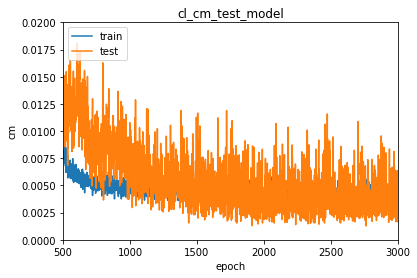

In [26]:
# summarize history for accuracy
plt.plot(history.history['custom_metric'])
plt.plot(history.history['val_custom_metric'])
plt.title('cl_cm_test_model')
plt.ylabel('cm')
plt.xlabel('epoch')
plt.xlim(500, 3000)
plt.ylim(0, 0.02)
plt.legend(['train', 'test'], loc='upper left')
plt.show()

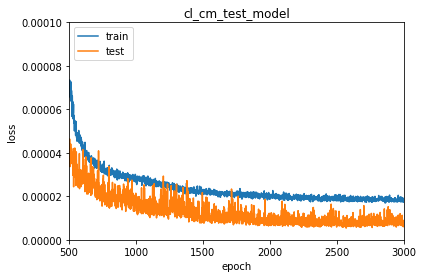

In [29]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('cl_cm_test_model')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.xlim(500, 3000)
plt.ylim(0, 0.0001)
plt.show()